## Opis problemu

Celem projektu jest analiza danych GPS statków i klasyfikacja ich zachowania (pobyt w porcie, dryf, kotwiczenie, rejs) na podstawie Współrzędnych geograficznych.

Model wykorzystuje dane sekwencyjne oraz cechy kinematyczne (prędkość, kierunek, zmiany ruchu), aby przewidywać stan jednostki w czasie.

---

## Kluczowy element systemu – dane o portach

Bardzo ważnym elementem pipeline’u jest baza portów wykorzystywana do wykrywania, czy statek znajduje się w porcie.

System używa tej bazy w połączeniu z algorytmem BallTree, który sprawdza odległość punktów GPS od najbliższych portów.

---

## Ograniczenie modelu

Skuteczność wykrywania portu zależy bezpośrednio od kompletności bazy portów.

W naszym przypadku dataset zawiera tylko porty europejskie (EU).

Oznacza to, że:

- jeśli statek znajduje się w porcie spoza Europy (np. w Chinach),
- model **nie wykryje go jako “In Port”**,
- ponieważ taki port nie istnieje w bazie referencyjnej.

---

## Wniosek

Model działa poprawnie w ramach dostępnej bazy portów, jednak jego zdolność do wykrywania pobytu w porcie jest ograniczona geograficznie i zależy od kompletności danych wejściowych o portach.

Użyte biblioteki: 
- `pandas` i `numpy` do przetwarzania danych,
- `torch` do budowy modeli sieci neuronowych,
- `sklearn` do skalowania danych i ewaluacji modeli,
- `matplotlib` i `seaborn` do wizualizacji.


### Wczytywanie danych

- **`load_data(file_path)`**  
  Funkcja wczytuje dane z pliku CSV do obiektu `DataFrame`.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import BallTree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from geopy.distance import geodesic

warnings.filterwarnings('ignore')


def load_data(file_path):
    df = pd.read_csv(file_path)
    if 'signaldate' in df.columns:
        df['signaldate'] = pd.to_datetime(df['signaldate'])
    return df


## Wykrywanie wartości odstających (outlierów)
---
## Funkcje pomocnicze

- **`haversine(...)`**  
  Oblicza odległość między dwoma punktami GPS (w metrach).

- **`calculate_bearing(...)`**  
  Oblicza kierunek ruchu (kąt 0–360°).  
  Jeśli wystąpi błąd (np. złe dane), zwraca `NaN`.

---

## Główna funkcja: `detect_and_handle_outliers(df)`

### 1. Przygotowanie danych
- Konwersja `LAT`, `LON` do liczb  
- Konwersja `signaldate` do daty  
- Sortowanie danych chronologicznie  

---

### 2. Iteracja po punktach

Dla każdego punktu:
- Jeśli brak współrzędnych → **outlier**
- Jeśli to pierwszy poprawny punkt → przyjmowany jako poprawny (referencja)

---

### 3. Obliczenia dla każdego punktu
Dla kolejnych punktów liczone są:

- **czas między punktami** (`time_diff`)
- **dystans** (metry)
- **prędkość SOG** (węzły)
- **kierunek COG**
- **przyspieszenie**
- **ROT (rate of turn)** – jak szybko zmienia się kierunek

---

## Warunki wykrywania outlierów

Punkt jest oznaczany jako **outlier**, jeśli spełnia którykolwiek z warunków:

1. **Brak danych GPS**
   - `LAT` lub `LON` jest puste (`NaN`)

2. **Niepoprawny czas**
   - `time_diff <= 0` (duplikaty lub błędne dane czasowe)

3. **Brak ruchu**
   - `dist_meters == 0`

4. **Zbyt duża prędkość**
   - `SOG > 45` węzłów

5. **Zbyt duże przyspieszenie**
   - `|acceleration| > 0.2 m/s²`

6. **Nierealistyczny skręt**
   - jeśli:
     - prędkość > 1 węzeł  
     - oraz `(SOG * |ROT| / 1100) > 1`

---

## Ważna logika

- Obliczenia zawsze są robione względem **ostatniego poprawnego punktu**
- Jeśli punkt jest outlierem → **nie wpływa na kolejne obliczenia**
- Tylko poprawne punkty aktualizują „referencję”

---

## Wynik

- Dodawana jest kolumna: `Outlier` (0 = OK, 1 = błędny)


---

## Podsumowanie

Algorytm usuwa punkty, które:
- mają błędne dane,
- powodują „nienaturalne” ruchy (za szybkie, za duże przyspieszenie, dziwne skręty),
- lub wyglądają jak błędy GPS.


In [2]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
def calculate_bearing(lat1, lon1, lat2, lon2):
    try:
       
        p_lat, p_lon = np.radians(lat1), np.radians(lon1)
        c_lat, c_lon = np.radians(lat2), np.radians(lon2)
        
        d_lon = c_lon - p_lon
        y = np.sin(d_lon) * np.cos(c_lat)
        x = np.cos(p_lat) * np.sin(c_lat) - np.sin(p_lat) * np.cos(c_lat) * np.cos(d_lon)
        return (np.degrees(np.arctan2(y, x)) + 360) % 360
    except Exception:
        return np.nan
        
HIGHEST_POSSIBLE_SOG=30
HIGHEST_POSSIBLE_ACCELERATION=0.03
HIGHEST_POSSIBLE_TURN=0.8
def detect_and_handle_outliers(df: pd.DataFrame, reverse: bool = False) -> pd.DataFrame:
    """Compute SOG, COG, acceleration, ROT and flag outliers.

    Each point is compared against the last VALID point, so outliers
    don't corrupt subsequent calculations.
    
    If reverse is True, checks backwards for outliers.
    """
    out_sog, out_cog, out_accel, out_rot, is_outlier = [], [], [], [], []

    last_valid_row = None
    last_valid_sog = 0.0
    last_valid_cog = np.nan
    
    iterator = df[::-1].iterrows() if reverse else df.iterrows()

    for index, row in iterator:
        if pd.isna(row["LAT"]) or pd.isna(row["LON"]):
            out_sog.append(np.nan)
            out_cog.append(np.nan)
            out_accel.append(np.nan)
            out_rot.append(np.nan)
            is_outlier.append(1)
            continue

        if last_valid_row is None:
            out_sog.append(0.0)
            out_cog.append(np.nan)
            out_accel.append(0.0)
            out_rot.append(0.0)
            is_outlier.append(0)
            last_valid_row = row
            last_valid_sog = 0.0
            continue

        if reverse:
            time_diff = (last_valid_row["signaldate"] - row["signaldate"]).total_seconds()
        else:
            time_diff = (row["signaldate"] - last_valid_row["signaldate"]).total_seconds()

        if time_diff <= 0:
            out_sog.append(last_valid_sog)
            out_cog.append(last_valid_cog)
            out_accel.append(0.0)
            out_rot.append(0.0)
            is_outlier.append(1)
            continue

        try:
            prev_pos = (float(last_valid_row["LAT"]), float(last_valid_row["LON"]))
            curr_pos = (float(row["LAT"]), float(row["LON"]))
            dist_meters = geodesic(prev_pos, curr_pos).meters
        except Exception:
            dist_meters = 0.0

        current_sog = (dist_meters / time_diff) * 1.94384
        
        if reverse:
            # Backwards
            current_cog = calculate_bearing(curr_pos[0], curr_pos[1], prev_pos[0], prev_pos[1])
            curr_sog_ms = current_sog * 0.51444
            prev_sog_ms = last_valid_sog * 0.51444
            current_accel = (prev_sog_ms - curr_sog_ms) / time_diff 
        else:
            current_cog = calculate_bearing(prev_pos[0], prev_pos[1], curr_pos[0], curr_pos[1])
            curr_sog_ms = current_sog * 0.51444
            prev_sog_ms = last_valid_sog * 0.51444
            current_accel = (curr_sog_ms - prev_sog_ms) / time_diff

        # Rot
        p_cog = last_valid_cog if not pd.isna(last_valid_cog) else current_cog
        delta_cog = (current_cog - p_cog + 180) % 360 - 180
        current_rot = (delta_cog / time_diff) * 60

        outlier_flag = 0
        if current_sog > HIGHEST_POSSIBLE_SOG:
            outlier_flag = 1
        elif abs(current_accel) > HIGHEST_POSSIBLE_ACCELERATION:
            outlier_flag = 1
        elif current_sog > 1.0 and (
            current_sog * abs(current_rot) / 1100
        ) > HIGHEST_POSSIBLE_TURN:
            outlier_flag = 1

        out_sog.append(current_sog)
        out_cog.append(current_cog)
        out_accel.append(current_accel)
        out_rot.append(current_rot)
        is_outlier.append(outlier_flag)

        if outlier_flag == 0:
            last_valid_row = row
            last_valid_sog = current_sog
            last_valid_cog = current_cog

    if reverse:
        out_sog.reverse()
        out_cog.reverse()
        out_accel.reverse()
        out_rot.reverse()
        is_outlier.reverse()


    df["Outlier"] = is_outlier

    return df


## Preprocessing danych i budowa cech



---

## Klasa `DataPreprocessor`

### Cel:
Czyszczenie danych oraz obliczenie podstawowych parametrów ruchu.

### Kroki:

1. **Usunięcie outlierów**
   - zostają tylko rekordy gdzie `Outlier == 0`

2. **Czyszczenie danych**
   - usunięcie brakujących `LAT`, `LON`
   - konwersja `signaldate` na datetime
   - usunięcie duplikatów czasu
   - sortowanie chronologiczne

3. **Obliczenie różnicy czasu (`dt`)**
   - czas między kolejnymi punktami (w sekundach)

4. **Wykrywanie przerw (`is_gap`)**
   - jeśli przerwa > 300 sekund → oznaczane jako gap

5. **Obliczenie dystansu (`distance_m`)**
   - odległość między kolejnymi punktami (haversine)
   - dla przerw → `NaN`

6. **Prędkość (`sog_ms`, `sog_knots`)**
   - m/s oraz węzły
   - ignorowane dla przerw

7. **Zmiana kierunku (`dcog_deg`)**
   - różnica kąta między kolejnymi punktami
   - uwzględnia „zawijanie” kąta (360°)

---

## Funkcja `assign_in_port`

### Cel:
Sprawdzenie, czy punkt znajduje się w pobliżu portu.

### Jak działa:
1. Wczytuje bazę portów z CSV
2. Tworzy strukturę `BallTree` (szybkie wyszukiwanie)
3. Dla każdego punktu:
   - znajduje najbliższy port
   - liczy odległość
4. Jeśli odległość ≤ 3000 m:
   - `In Port = 1`
   - w przeciwnym razie `0`

### Uwagi:
- Jeśli kolumna `In Port` już istnieje → nic nie robi
- Jeśli błąd wczytania portów → wszystkie punkty = 0

---

## Funkcja `build_features_and_route`

### Cel:
Budowa cech do modelu lstm.

### Główna idea:
Tworzy **okna czasowe (sekwencje)** z danych.

---

### Dla każdego okna:

1. **Podstawowe dane**
   - prędkość (`sog`)
   - zmiana kierunku (`dcog`)
   - pozycje GPS

2. **Cechy globalne dla okna:**

- **`dist_m`**
  - odległość między początkiem i końcem okna

- **`window_speed_ms`**
  - średnia prędkość w oknie

- **`spread_m`**
  - jak bardzo punkty są rozproszone (czy statek stoi / krąży)

- **`efficiency`**
  - stosunek drogi prostej do faktycznej trasy  
  - blisko 1 = ruch prosty  
  - małe = dużo zakrętów

- **`window_turn_sum`**
  - suma zmian kierunku (ile skręca)

- **`shape_index`**
  - stosunek dystansu do rozproszenia  
  - mówi czy ruch jest „wydłużony” czy „chaotyczny”

---

### Dane wejściowe modelu

Dla każdego punktu w oknie tworzony jest wektor:
[sog, dcog, window_speed, spread, dist, efficiency, turn_sum, shape_index]

---

### Etykieta

- Środkowy punkt okna decyduje:
  - `1` → w porcie  
  - `0` → poza portem  

---

## Wynik

Funkcja zwraca:
- `X_sequences` → dane wejściowe (sekwencje)
- `is_port_sequence` → etykiety
- `indices` → indeksy środkowych punktów

---

## Podsumowanie

Pipeline:
1. Czyszczenie danych
2. Obliczenie ruchu (prędkość, kierunek)
3. Sprawdzenie portów
4. Budowa sekwencji czasowych


In [3]:
class DataPreprocessor:
    
    def process(self, df: pd.DataFrame) -> pd.DataFrame:
        df_proc = df[df["Outlier"] == 0].reset_index(drop=True).copy()
        
        df_proc = df_proc.dropna(subset=["LAT", "LON"]).reset_index(drop=True)
        df_proc["signaldate"] = pd.to_datetime(df_proc["signaldate"])
        df_proc = df_proc.drop_duplicates(subset=["signaldate"])
        df_proc = df_proc.sort_values("signaldate").reset_index(drop=True)

        dt = np.empty(len(df_proc))
        dt[0] = np.nan
        dt[1:] = df_proc["signaldate"].diff().dt.total_seconds().values[1:]
        df_proc["dt"] = dt
        
        is_gap = np.zeros(len(df_proc), dtype=bool)
        is_gap[0] = True
        is_gap[1:] = dt[1:] > 300
        df_proc["is_gap"] = is_gap.astype(int)
        
        lat = df_proc["LAT"].values
        lon = df_proc["LON"].values
        dist = np.empty(len(df_proc))
        dist[0] = np.nan
        dist[1:] = haversine(lat[:-1], lon[:-1], lat[1:], lon[1:])
        dist[is_gap] = np.nan
        df_proc["distance_m"] = dist
        
        with np.errstate(divide="ignore", invalid="ignore"):
            sog_ms = dist / dt
        sog_ms[is_gap] = np.nan
        df_proc["sog_ms"] = sog_ms
        df_proc["sog_knots"] = sog_ms * 1.943844
        
        raw_cog = np.empty(len(df_proc))
        raw_cog[0] = np.nan
        raw_cog[1:] = calculate_bearing(lat[:-1], lon[:-1], lat[1:], lon[1:])
        
        dcog = np.empty(len(df_proc))
        dcog[:2] = np.nan
        dcog[2:] = (raw_cog[2:] - raw_cog[1:-1] + 180) % 360 - 180
        dcog[is_gap] = np.nan
        df_proc["dcog_deg"] = dcog
        
        return df_proc

def assign_in_port(df: pd.DataFrame, ports_csv_path: str, radius_m: float = 5000.0) -> pd.DataFrame:
    
    df_out = df.copy()
    
    # Jeśli ma kolumnę z etykietą, to nie musimy szukać na nowo (Trening)
    if "In Port" in df_out.columns:
        return df_out
        
    try:
        ports_df = pd.read_csv(ports_csv_path)
    except Exception as e:
        print(f"Błąd wczytywania bazy portów: {e}")
        df_out["In Port"] = 0
        return df_out
        
    EARTH_RADIUS_M = 6_371_000
    coords_rad_ports = np.radians(ports_df[["LAT", "LON"]].values)
    tree = BallTree(coords_rad_ports, metric="haversine")
    
    coords_rad_query = np.radians(df_out[["LAT", "LON"]].values)
    dist_rad, _ = tree.query(coords_rad_query, k=1)
    dist_m = dist_rad[:, 0] * EARTH_RADIUS_M
    
    df_out["In Port"] = (dist_m <= radius_m).astype(int)
    return df_out

def build_features_and_route(df: pd.DataFrame, window_size: int = 5):
    
    df = df.copy()
    sog = df["sog_knots"].fillna(0).values
    dcog = df["dcog_deg"].fillna(0).values
    lats = df["LAT"].values
    lons = df["LON"].values
    timestamps = df["signaldate"].values
    
    is_port = df["In Port"].values == 1 if "In Port" in df.columns else np.zeros(len(df), dtype=bool)
    
    ptp_dists = haversine(lats[:-1], lons[:-1], lats[1:], lons[1:])
    ptp_dists = np.insert(ptp_dists, 0, 0.0)

    X_sequences, is_port_sequence, indices = [], [], []
    
    for i in range(len(df) - window_size + 1):
        w_lats = lats[i : i + window_size]
        w_lons = lons[i : i + window_size]
        
        dist_m = haversine(np.array([w_lats[0]]), np.array([w_lons[0]]), np.array([w_lats[-1]]), np.array([w_lons[-1]]))[0]
        time_delta_seconds = (timestamps[i + window_size - 1] - timestamps[i]) / np.timedelta64(1, 's')
        window_speed_ms = dist_m / time_delta_seconds if time_delta_seconds > 0 else 0.0

        c_lat, c_lon = w_lats.mean(), w_lons.mean()
        dists_to_center = haversine(w_lats, w_lons, np.full(window_size, c_lat), np.full(window_size, c_lon))
        spread_m = dists_to_center.max()
        
        path_dist = np.sum(ptp_dists[i+1 : i+window_size])
        efficiency = dist_m / path_dist if path_dist > 0 else 0.0
        window_turn_sum = np.sum(np.abs(dcog[i : i + window_size]))
        shape_index = dist_m / (spread_m + 1.0)

        seq = []
        for j in range(window_size):
            seq.append([sog[i+j], dcog[i+j], window_speed_ms, spread_m, dist_m, efficiency, window_turn_sum, shape_index])
            
        X_sequences.append(seq)
        
        center_idx = i + window_size // 2
        is_port_sequence.append(is_port[center_idx])
        indices.append(center_idx)
        
    return np.array(X_sequences), np.array(is_port_sequence), np.array(indices)


## Model LSTM do analizy ruchu statku

### Architektura (`SimpleSeaLSTM`)

Model jest siecią neuronową typu **LSTM (Long Short-Term Memory)**, przystosowaną do danych sekwencyjnych (trajektorii GPS).

#### Struktura:
- **Wejście:** sekwencje cech (8 cech na punkt)
- **LSTM:**
  - 2 warstwy
  - 64 neurony (hidden size)
  - bidirectional (analiza w przód i w tył)
  - dropout = 0.2 (redukcja overfittingu)
- **Agregacja:**
  - średnia po czasie (`mean pooling`)
- **Wyjście:**
  - warstwa liniowa (`Linear`)
  - 3 klasy (np. różne typy ruchu)

---

### Jak działa forward:

1. Sekwencja trafia do LSTM → model uczy się zależności czasowych  
2. Wyniki z całej sekwencji są uśredniane  
3. Warstwa liniowa zamienia to na klasy  

---

## Wrapper modelu (`SimpleSeaModelWrapper`)

### Funkcje:

- **Trening (`fit`)**
  - używa `CrossEntropyLoss`
  - optymalizator: Adam
  - batch size: 64
  - zapisuje loss dla każdej epoki

- **Scheduler**
  - zmniejsza learning rate jeśli loss nie spada

- **Predykcja (`predict`)**
  - zwraca:
    - przewidywaną klasę
    - confidence (%)

- **Wizualizacja**
  - wykres loss vs epoka

---

## Dodatkowy model (`PortManeuverNN`)

-nie zaimplementowany docelowo bedzie sie załączać jeżeli statek będzie w porcie i będzie odpowiadał za predykcje stanów  In Port Shifting,In Port Departure, In Port Arrival 
-bardzo możliwe że zrezygnujemy z tego na rzecz prostego algorytmu 

---

## Podsumowanie

Model:
- analizuje **sekwencje ruchu statku**
- uczy się wzorców czasowych (LSTM)
- klasyfikuje zachowanie na 3 klasy (anchor,adrift,voyage)

Wrapper:
- upraszcza trening, predykcję i analizę wyników

In [4]:
class SimpleSeaLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, dropout=0.2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out_mean = torch.mean(out, dim=1)
        return self.fc(out_mean)

class SimpleSeaModelWrapper:
    def __init__(self, epochs=20, lr=0.001, class_weights=None):
        self.epochs = epochs
        self.lr = lr
        self.model = SimpleSeaLSTM()
        self.history = {'train_loss': []}
        
        if class_weights is not None:
            weight_tensor = torch.tensor(class_weights, dtype=torch.float32)
            self.criterion = nn.CrossEntropyLoss(weight=weight_tensor)
        else:
            self.criterion = nn.CrossEntropyLoss()
            
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3)

    def fit(self, X_seq: np.ndarray, y: np.ndarray):
        if len(X_seq) == 0: return
        self.model.train()
        X_tensor = torch.tensor(X_seq, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)
        loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=64, shuffle=True)

        for epoch in range(self.epochs):
            epoch_loss = 0.0
            for batch_x, batch_y in loader:
                self.optimizer.zero_grad()
                loss = self.criterion(self.model(batch_x), batch_y)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(loader)
            self.history['train_loss'].append(avg_loss)
            self.scheduler.step(avg_loss)
            
    def plot_learning_curve(self):
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(self.history['train_loss']) + 1), self.history['train_loss'], marker='o', label='Train Loss')
        plt.title('Krzywa uczenia (Loss per Epoch)')
        plt.xlabel('Epoka')
        plt.ylabel('Strata (CrossEntropy Loss)')
        plt.grid(True)
        plt.legend()
        plt.show()

    def predict(self, X_seq: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        if len(X_seq) == 0: return np.array([]), np.array([])
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_seq, dtype=torch.float32)
            probs = torch.softmax(self.model(X_tensor), dim=1)
            confs, preds = torch.max(probs, dim=1)
        return preds.numpy(), confs.numpy() * 100.0

class PortManeuverNN:
    def __init__(self): pass
    def fit(self, X, y): pass
    def predict(self, X) -> np.ndarray: return np.zeros(len(X), dtype=int)


## Trenowanie modelu 

Funkcja `train_hierarchical_model` buduje i trenuje model podzielony na dwa przypadki:
- **ruch na morzu**
- **ruch w porcie**

---

## 1. Przygotowanie danych

- Tworzone są sekwencje:
  - `X_seq` → dane wejściowe
  - `is_port_seq` → czy punkt jest w porcie
  - `idxs` → indeksy

- Pobierane są etykiety:
  - `labels = operation_id`

---

## 2. Podział danych

- **Sea (morze):**
  - `sea_mask = ~is_port_seq`
  - tylko dane poza portem

- **Etykiety dla morza:**
  - `y_sea = labels - 2`
  - przesunięcie klas o 2 indeksy z (2,3,4) do (0,1,2) (anchor,adrift,voyage)

---

## 3. Balansowanie klas

- Liczona jest liczba próbek każdej klasy
- Wyznaczane są wagi:
  - rzadsze klasy → większa waga
- używane w funkcji straty (`CrossEntropyLoss`)

---

## 4. Skalowanie danych

- `StandardScaler` normalizuje cechy
- dane są spłaszczane → skalowane → przywracane do sekwencji

---

## 5. Trenowanie modelu morskiego

- używany jest `SimpleSeaModelWrapper`
- trenowany tylko na danych poza portem

---



## 6. Wynik

Funkcja zwraca słownik:
- `sea_model` → model dla morza
- `port_model` → model dla portu ( zwraca "port_stay" narazie bo nie jest zaimplementowany)
- `scaler` → do normalizacji danych

---

## Podsumowanie

Model jest **hierarchiczny**:
1. Najpierw sprawdza: port vs morze
2. Następnie:
   - morze → klasyfikacja LSTM
   - port → osobny model (pusty narazie)


In [5]:
def train_hierarchical_model(train_df: pd.DataFrame, epochs: int = 25, window_size: int = 5) -> dict:
    print("Budowanie cech i okien dla treningu...")
    X_seq, is_port_seq, idxs = build_features_and_route(train_df, window_size=window_size)
    labels = train_df["operation_id"].values[idxs]
    
    sea_mask = ~is_port_seq
    X_sea = X_seq[sea_mask]
    y_sea = (labels[sea_mask] - 2).astype(int) 
    
    counts = np.bincount(y_sea, minlength=3)
    counts = np.maximum(counts, 1)
    weights = 1.0 / np.power(counts, 0.25)
    weights = (weights / np.sum(weights)) * 3.0
    
    sea_model = SimpleSeaModelWrapper(epochs=epochs, class_weights=weights)
    scaler = StandardScaler()
    if len(X_sea) > 0:
        N, W, F = X_sea.shape
        X_sea_scaled = scaler.fit_transform(X_sea.reshape(-1, F)).reshape(N, W, F)
        print(f"Trenowanie modelu morskiego na {len(X_sea)} oknach...")
        sea_model.fit(X_sea_scaled, y_sea)
        
    port_model = PortManeuverNN()
    if is_port_seq.any():
        print(f"Trenowanie modelu portowego na {is_port_seq.sum()} oknach...")
        port_model.fit(X_seq[is_port_seq], np.zeros(is_port_seq.sum(), dtype=int))
        
    print("Trening zakończony pomyślnie.\n")
    return {"sea_model": sea_model, "port_model": port_model, "scaler": scaler}

## Predykcja modelu 

Funkcja wykonuje pełny pipeline predykcji na nowych danych.

---

## 1. Przygotowanie

- Pobierane są:
  - `sea_model` (model LSTM)
  - `port_model` (model portowy)
  - `scaler` (normalizacja)

- Dodawana jest informacja:
  - czy punkt jest w porcie (`assign_in_port`)

- Budowane są sekwencje (`build_features_and_route`)

---

## 2. Inicjalizacja wyników

- Tworzona jest kolumna:
  - `predicted_state` (domyślnie `"adrift"`)
  - `confidence` (domyślnie `50%`)

---

## 3. Predykcja dla portu

- Jeśli punkt jest w porcie:
  - stan = `"port_stay"`
  - confidence = `95%`
- (tu nie używamy modelu — decyzja jest prosta)

---

## 4. Predykcja dla morza

- Dla punktów poza portem:
  1. Dane są skalowane (`scaler`)
  2. Model LSTM przewiduje klasę
  3. Klasy mapowane na nazwy:
     - `0 → anchor`
     - `1 → adrift`
     - `2 → voyage`
  4. Zapisywane są predykcje i confidence

---

## 5. Uzupełnianie braków

- Wartości są uzupełniane:
  - `ffill` (do przodu)
  - `bfill` (do tyłu)

---

## Wynik

Zwracany jest DataFrame z:
- `predicted_state`
- `confidence`

---

## Ewaluacja (`evaluate_pipeline`)

### Cel:
Sprawdzenie jakości modelu (accuracy)

---

### Kroki:

1. Usunięcie kolumny `"In Port"`
   - żeby wymusić ponowne liczenie (BallTree)

2. Predykcja:
   - wywołanie `predict_model`

3. Mapowanie etykiet:
   - `operation_id → nazwy klas`

4. Czyszczenie danych:
   - usunięcie braków (`NaN`)

5. Obliczenie accuracy:
   - porównanie predykcji z prawdą

---

## Wynik

- `accuracy` (% poprawnych predykcji)
- `preds_df` (pełne predykcje)
- `y_true_clean` (prawdziwe etykiety)
- `y_pred_clean` (przewidywane etykiety)

---

## Podsumowanie

Pipeline:
1. Wykrycie portu (BallTree)
2. Podział:
   - port → prosta reguła
   - morze → model LSTM
3. Predykcja + confidence
4. Ewaluacja accuracy


In [6]:
def predict_model(trained_dict: dict, df: pd.DataFrame, ports_csv_path: str, window_size: int = 5) -> pd.DataFrame:
    sea_model = trained_dict["sea_model"]
    port_model = trained_dict["port_model"]
    scaler = trained_dict.get("scaler")
    
    # Przed predykcją używamy BallTree do znalezienia portów
    df_with_port = assign_in_port(df, ports_csv_path, radius_m=5000.0)
    X_seq, is_port_seq, idxs = build_features_and_route(df_with_port, window_size=window_size)
    
    result = df_with_port.copy()
    if "predicted_state" not in result.columns: result["predicted_state"] = "adrift"
    if "confidence" not in result.columns: result["confidence"] = 50.0
    
    if is_port_seq.any():
        result.iloc[idxs[is_port_seq], result.columns.get_loc("predicted_state")] = "port_stay"
        result.iloc[idxs[is_port_seq], result.columns.get_loc("confidence")] = 95.0
        
    if (~is_port_seq).any():
        X_sea = X_seq[~is_port_seq]
        if scaler is not None and len(X_sea) > 0:
            N, W, F = X_sea.shape
            X_sea = scaler.transform(X_sea.reshape(-1, F)).reshape(N, W, F)
            
        sea_preds, sea_confs = sea_model.predict(X_sea)
        SEA_STATE_MAP = {0: "anchor", 1: "adrift", 2: "voyage"}
        pred_strings = [SEA_STATE_MAP.get(p, "adrift") for p in sea_preds]
        
        result.iloc[idxs[~is_port_seq], result.columns.get_loc("predicted_state")] = pred_strings
        result.iloc[idxs[~is_port_seq], result.columns.get_loc("confidence")] = sea_confs
        
    result["predicted_state"] = result["predicted_state"].ffill().bfill()
    result["confidence"] = result["confidence"].ffill().bfill()
    return result

def evaluate_pipeline(trained_dict: dict, df_true: pd.DataFrame, ports_csv_path: str, dataset_name: str = ""):
    
    df_eval = df_true.copy()
        
    preds_df = predict_model(trained_dict, df_eval, ports_csv_path, window_size=5)
    
    ID_TO_STATE = {1: "port_stay", 2: "anchor", 3: "adrift", 4: "voyage"}
    y_true_str = df_true["operation_id"].map(ID_TO_STATE)
    y_pred_str = preds_df["predicted_state"]
    
    valid_mask = y_pred_str.notna() & y_true_str.notna()
    y_true_clean = y_true_str[valid_mask]
    y_pred_clean = y_pred_str[valid_mask]
    
    acc = accuracy_score(y_true_clean, y_pred_clean)
    # print(f"[{dataset_name}] Accuracy: {acc * 100:.2f}%")
    
    return acc, preds_df, y_true_clean, y_pred_clean

## Post-processing danych AIS i wyznaczanie tras

Moduł post-processingu działa na wynikach predykcji. Na podstawie głównych stanów oraz kinematyki wyznacza mikromanewry, momenty przekraczania granic portu oraz pełne trasy statku.

---

## 1. Detekcja manewrów (kinematyka)

* **Ruch w porcie (`add_in_port_shifting`):**
* warunek: statek jest w porcie (`In Port == 1`)
* warunek: porusza się z prędkością manewrową (0.5 - 4.0 węzła)
* wynik: kolumna `In Port Shifting` (0/1)


* **Zwrot na morzu (`add_at_sea_turn`):**
* warunek: statek jest w trasie (`At Sea Voyage == 1`)
* warunek: wysoka prędkość (`> 5.0` węzła) i znaczna zmiana kursu (`|dcog_deg| >= 5.0°`)
* wynik: kolumna `At Sea Turn` (0/1)



---

## 2. Zdarzenia punktowe (przejścia stanów)

* Zmiany badane są za pomocą przesunięcia wierszy (`shift(1)`).
* **Wejście do portu (`add_in_port_arrival`):**
* poprzednio: `0` (poza portem)
* obecnie: `1` (w porcie)
* wynik: kolumna `In Port Arrival` (punktowe zdarzenie)


* **Wyjście z portu (`add_in_port_departure`):**
* poprzednio: `1` (w porcie)
* obecnie: `0` (poza portem)
* wynik: kolumna `In Port Departure` (punktowe zdarzenie)



---

## 3. Przypisywanie portów (geofencing)

* **Mapowanie kodów LOCODE (`assign_port_locodes`):**
* wykorzystuje strukturę `BallTree` (metryka haversine) do szybkiego wyszukiwania
* analizuje tylko punkty, gdzie `In Port == 1`
* warunek: odległość do najbliższego portu z bazy mniejsza niż limit `radius_m` (w naszym przypadku 5km)
* wynik: tymczasowa kolumna `temp_locode` (lub `Null`, jeśli statek jest za daleko)



---

## 4. Generowanie tras między portami

* **Wyznaczanie segmentów (`fill_departure_destination`):**
* ciągłe sygnały `In Port == 1` są grupowane w pojedyncze wizyty
* port wyjścia (A) i wejścia (B) przypisywany jest do wszystkich wierszy pomiędzy wizytami
* podróż przed pierwszym wykrytym portem w danych → `Departure Port Locode = Null`
* podróż po ostatnim wykrytym porcie w danych → `Destination Port Locode = Null`
* wynik: wypełnione kolumny `Departure Port Locode` oraz `Destination Port Locode`



---

## Podsumowanie

Proces post-processingu działa **kaskadowo**:

1. Najpierw wyznacza: manewry (in port shifting,at sea turn) na podstawie SOG/DCOG oraz zmiany stanów (arrival/departure).
2. Następnie mapuje: lokalizacje postojów na konkretne kody LOCODE z zewnętrznej bazy.
3. Na koniec: rekonstruuje trasy, rozciągając wykryte kody portów na segmenty między wizytami, uwzględniając skrajne odcinki na morzu.

In [7]:
def add_in_port_shifting(df: pd.DataFrame) -> pd.DataFrame:
    min_sog = 0.5  
    max_sog = 4.0  
    mask = (df['In Port'] == 1) & (df['sog_knots'].between(min_sog, max_sog))
    df['In Port Shifting'] = mask.astype(np.int8)
    return df

def add_at_sea_turn(df: pd.DataFrame) -> pd.DataFrame:
    min_dcog = 5.0  
    min_sog_ms = 2.572  
    mask = (df['At Sea Voyage'] == 1) & (df['sog_ms'] > min_sog_ms) & (df['dcog_deg'].abs() >= min_dcog)
    df['At Sea Turn'] = mask.astype(np.int8)
    return df
    
def add_in_port_arrival(df: pd.DataFrame) -> pd.DataFrame:
    
    was_in_port = df['In Port'].shift(1)
    is_in_port = df['In Port']
    
    mask = (was_in_port == 0) & (is_in_port == 1)
    
    df['In Port Arrival'] = mask.astype(np.int8)
    return df

def add_in_port_departure(df: pd.DataFrame) -> pd.DataFrame:

    was_in_port = df['In Port'].shift(1)
    is_in_port = df['In Port']
    

    mask = (was_in_port == 1) & (is_in_port == 0)
    
    df['In Port Departure'] = mask.astype(np.int8)
    return df

def assign_port_locodes(df: pd.DataFrame, ports_csv_path: str, radius_m: float = 5000.0) -> pd.DataFrame:

    df_out = df.copy()
    df_out["temp_locode"] = None
    
    try:
        ports_df = pd.read_csv(ports_csv_path)
    except Exception as e:
        print(f"Błąd wczytywania bazy portów: {e}")
        return df_out

    EARTH_RADIUS_M = 6_371_000
    coords_rad_ports = np.radians(ports_df[["LAT", "LON"]].values)
    tree = BallTree(coords_rad_ports, metric="haversine")
    

    in_port_mask = df_out["In Port"] == 1
    
    if in_port_mask.sum() > 0:
        coords_rad_query = np.radians(df_out.loc[in_port_mask, ["LAT", "LON"]].values)
        dist_rad, indices = tree.query(coords_rad_query, k=1)
        dist_m = dist_rad[:, 0] * EARTH_RADIUS_M
        
        valid_dist = dist_m <= radius_m
        locodes = ports_df.iloc[indices[:, 0]]["LOCODE"].values
        

        df_out.loc[in_port_mask, "temp_locode"] = np.where(valid_dist, locodes, None)
    

    
    return df_out

import pandas as pd

def fill_departure_destination(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    n = len(df)
    dep_ports = [None] * n
    dest_ports = [None] * n
    
    in_port_flags = df['In Port'].values
    locodes = df['temp_locode'].values
    
    # 1. PĘTLA DO PRZODU: przypisujemy port wypłynięcia (Departure)
    current_dep = None
    for i in range(n):
        if in_port_flags[i] == 1 and pd.notna(locodes[i]):
            current_dep = locodes[i]
        
        if in_port_flags[i] == 0:
            dep_ports[i] = current_dep

    # 2. PĘTLA DO TYŁU: przypisujemy port docelowy (Destination)
    current_dest = None
    for i in range(n - 1, -1, -1):
        if in_port_flags[i] == 1 and pd.notna(locodes[i]):
            current_dest = locodes[i]
            
        if in_port_flags[i] == 0:
            dest_ports[i] = current_dest

    # 3. WYZEROWANIE PIERWSZEJ I OSTATNIEJ PODRÓŻY W DATASECIE
    
    # A) Szukamy pierwszej podróży (pierwszy ciąg In Port == 0)
    for i in range(n):
        if in_port_flags[i] == 0:
            # Znaleźliśmy początek pierwszej podróży. Zerujemy aż do wejścia do portu.
            for j in range(i, n):
                if in_port_flags[j] == 1:
                    break
                dep_ports[j] = None
                dest_ports[j] = None
            break 

    # B) Szukamy ostatniej podróży (ostatni ciąg In Port == 0, idąc od końca)
    for i in range(n - 1, -1, -1):
        if in_port_flags[i] == 0:
            
            for j in range(i, -1, -1):
                if in_port_flags[j] == 1:
                    break
                dep_ports[j] = None
                dest_ports[j] = None
            break # Zrobione, przerywamy pętlę główną

    df["Departure Port Locode"] = dep_ports
    df["Destination Port Locode"] = dest_ports
    
    return df.drop(columns=["temp_locode", "port_group"], errors='ignore')

## Uruchomienie pipeline’u do trenowania

Kod wykonuje cały pipeline: wczytanie i oczyszczenie danych, podział na zbiory, trening modelu, ewaluację oraz wizualizację wyników.
do 2 pierwszych zmiennych trzeba podać ścieżki do datasetu z: danymi sklasyfikowanymi do treningu, do portów.

Wczytywanie i preprocesing danych...
Rozmiary zbiorów (wiersze) - Train: 10079, Val: 2160, Test: 2160

Budowanie cech i okien dla treningu...
Trenowanie modelu morskiego na 9795 oknach...
Trenowanie modelu portowego na 275 oknach...
Trening zakończony pomyślnie.



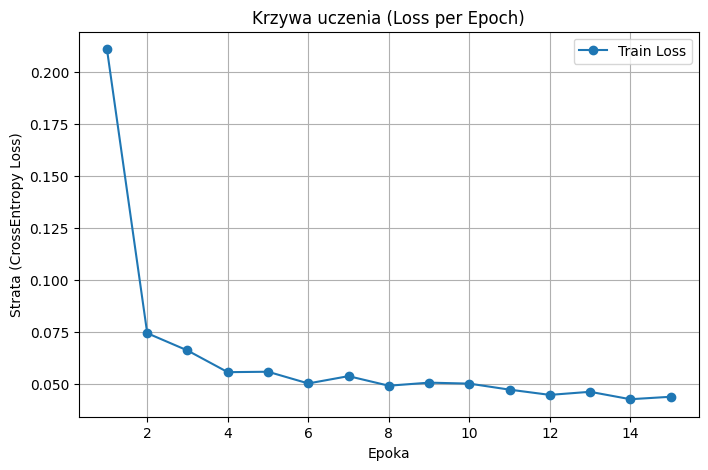


=== WYNIKI EWALUACJI ===


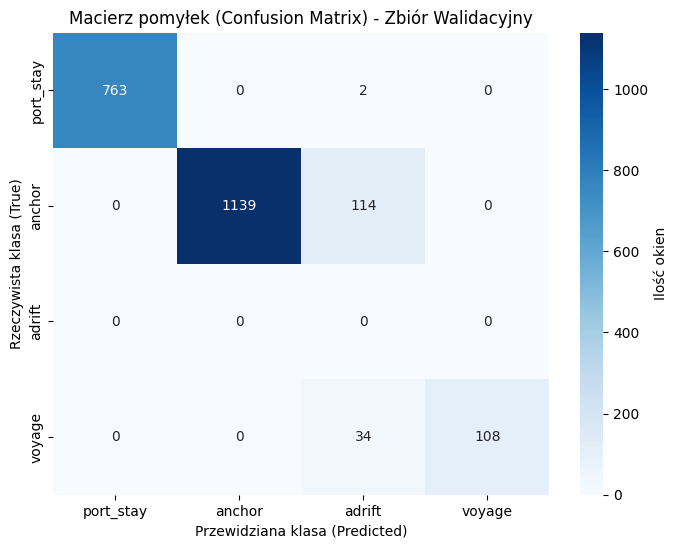

In [8]:

    # --- PODAJ SWOJE ŚCIEŻKI TUTAJ ---
TRAIN_CSV = r"C:\Users\TMMsi\Desktop\marine_recognition\data\raw\classified\Ship_Operation_example_dataset_classified.csv"
PORTS_CSV = r"C:\Users\TMMsi\Desktop\marine_recognition\data\ports\EU_Port_Codes.csv"

    
# 1. Wczytanie i globalny preprocesing
print("Wczytywanie i preprocesing danych...")
df_all = load_data(TRAIN_CSV)

df_all = detect_and_handle_outliers(df_all)


preprocessor = DataPreprocessor()
df_all_proc = preprocessor.process(df_all)


    # 2. Podział na zbiory (Train: 70%, Val: 15%, Test: 15%)
n = len(df_all_proc)
train_idx = int(n * 0.70)
val_idx = int(n * 0.85)

df_train = df_all_proc.iloc[:train_idx].copy()
df_val = df_all_proc.iloc[train_idx:val_idx].copy()
df_test = df_all_proc.iloc[val_idx:].copy()
print(f"Rozmiary zbiorów (wiersze) - Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}\n")


    # 3. Trenowanie modelu
models = train_hierarchical_model(df_train, epochs=15, window_size=10)

    # 4. Rysowanie krzywej uczenia z loss-em
models["sea_model"].plot_learning_curve()

    # 5. metryki Accuracy
print("\n=== WYNIKI EWALUACJI ===")
_ = evaluate_pipeline(models, df_train, PORTS_CSV, dataset_name="Train")
_, preds_val_df, y_true_val, y_pred_val = evaluate_pipeline(models, df_val, PORTS_CSV, dataset_name="Validation")
_, preds_test_df, y_true_test, y_pred_test = evaluate_pipeline(models, df_test, PORTS_CSV, dataset_name="Test")
    # 6. Rysowanie Confusion Matrix na zbiorze Treningowym
labels = ["port_stay", "anchor", "adrift", "voyage"]
cm = confusion_matrix(y_true_test, y_pred_test, labels=labels)

    
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Ilość okien'})
plt.title('Macierz pomyłek (Confusion Matrix) - Zbiór Walidacyjny')
plt.ylabel('Rzeczywista klasa (True)')
plt.xlabel('Przewidziana klasa (Predicted)')
plt.show()

## uruchomienie pipelinu do predykcji

In [9]:
#nalezy podac swoje ścieżki
NEW_DATA_CSV = r"C:\Users\TMMsi\Desktop\marine_recognition\data\raw\classified\Ship_Operation_example_dataset_classified.csv"
FINAL_OUTPUT_PATH = r"C:\Users\TMMsi\Desktop\marine_recognition\data\processed\final_inference_results.csv"



# 1. Wczytanie i przygotowanie surowych danych
df_new = load_data(NEW_DATA_CSV)
df_new = detect_and_handle_outliers(df_new)

# 2. Kinematyka (dt, sog, dcog itp.)
preprocessor_new = DataPreprocessor()
df_new_proc = preprocessor_new.process(df_new)
df_new_proc.to_csv(r"C:\Users\TMMsi\Desktop\marine_recognition\data\processed\final_inference_results_pre.csv")
# 3. Predykcja modelu
_, df_classified, _, _ = evaluate_pipeline(models, df_new_proc, PORTS_CSV, dataset_name="Inference")

# 4. Post-processing (Linijka po linijce)
print("Uruchamianie post-processingu dla wyników klasyfikacji...")


df_classified = add_in_port_shifting(df_classified)
df_classified = add_at_sea_turn(df_classified) 
df_classified = add_in_port_arrival(df_classified)
df_classified = add_in_port_departure(df_classified)

# Geofencing (radius 15km)
df_classified = assign_port_locodes(df_classified, PORTS_CSV, radius_m=15000.0)

# Rekonstrukcja tras (Departure/Destination)
df_classified = fill_departure_destination(df_classified)

# 5. Zapisanie gotowego pliku
df_classified.to_csv(FINAL_OUTPUT_PATH, index=False)

print(f"\nSukces! Pełna klasyfikacja i post-processing zakończone.")
print(f"Wynik zapisano w: {FINAL_OUTPUT_PATH}")

#Sprawdzenie ile manewrów(sea turn,port Shifting) wykryto
print("\nStatystyki wykrytych stanów:")
cols_to_check = ['In Port Shifting', 'At Sea Turn', 'In Port Arrival', 'In Port Departure']
print(df_classified[cols_to_check].sum())

Uruchamianie post-processingu dla wyników klasyfikacji...

Sukces! Pełna klasyfikacja i post-processing zakończone.
Wynik zapisano w: C:\Users\TMMsi\Desktop\marine_recognition\data\processed\final_inference_results.csv

Statystyki wykrytych stanów:
In Port Shifting      11
At Sea Turn          124
In Port Arrival        1
In Port Departure      1
dtype: int64
